FUNCIONARIOS PÚBLICOS DEL PARAGUAY

In [1]:
import pandas as pd
import os

columnas = ['anio', 'mes',    'descripcionEntidad',       'sexo',    'montoDevengado',   'codigoPersona']


fp_feb2024_fil = pd.read_csv('D:/GitHub/funpublicospy/nomina_2024-02.csv',    sep=",",encoding='ISO-8859-1', decimal=',', usecols=columnas)

nombres_campos = list(fp_feb2024_fil.columns)
nombres_campos

C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\978941124.py:7: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  fp_dic2013_fil = pd.read_csv('D:/GitHub/funpublicospy/nomina_2024-02.csv',    sep=",",encoding='ISO-8859-1', decimal=',', usecols=columnas)


['anio',
 'mes',
 'descripcionEntidad',
 'codigoPersona',
 'sexo',
 'montoDevengado']

# Carga de las bases para los otros periodos

In [2]:
fp_dic2013_fil = pd.read_csv('C:/FP/nomina_2013-12.csv',    sep=",",encoding='ISO-8859-1', decimal=',', usecols=columnas)

nombres_campos = list(fp_dic2013_fil.columns)
nombres_campos


C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\3250526180.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  fp_dic2013_fil = pd.read_csv('C:/FP/nomina_2013-12.csv',    sep=",",encoding='ISO-8859-1', decimal=',', usecols=columnas)


['anio',
 'mes',
 'descripcionEntidad',
 'codigoPersona',
 'sexo',
 'montoDevengado']

Leer todas las bases de kuna 

In [3]:
import glob
#generar un bucle para leer todos los años
# Obtener una lista de los nombres de archivo de todos los archivos CSV en un directorio
archivos_csv = glob.glob('C:/FP/nomina_2023*.csv')
archivos_csv


['C:/FP\\nomina_2023-01.csv',
 'C:/FP\\nomina_2023-02.csv',
 'C:/FP\\nomina_2023-03.csv',
 'C:/FP\\nomina_2023-04.csv',
 'C:/FP\\nomina_2023-05.csv',
 'C:/FP\\nomina_2023-06.csv',
 'C:/FP\\nomina_2023-07.csv',
 'C:/FP\\nomina_2023-08.csv',
 'C:/FP\\nomina_2023-09.csv',
 'C:/FP\\nomina_2023-10.csv',
 'C:/FP\\nomina_2023-11.csv',
 'C:/FP\\nomina_2023-12.csv',
 'C:/FP\\nomina_2023-13.csv']

# Iterar sobre la lista de archivos CSV y cargar cada archivo en un DataFrame separado


In [4]:
columnas = ['anio', 'mes',    'descripcionEntidad',       'sexo',    'montoDevengado',   'codigoPersona']

dfs = []
for archivo in archivos_csv:
    df = pd.read_csv(archivo,       sep=",",    encoding='ISO-8859-1',   decimal=',',  usecols=columnas)
    dfs.append(df)


C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\3520521737.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo,       sep=",",    encoding='ISO-8859-1',   decimal=',',  usecols=columnas)
C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\3520521737.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo,       sep=",",    encoding='ISO-8859-1',   decimal=',',  usecols=columnas)
C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\3520521737.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo,       sep=",",    encoding='ISO-8859-1',   decimal=',',  usecols=columnas)
C:\Users\Diego\AppData\Local\Temp\ipykernel_18416\3520521737.py:5: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(

#juntar las bases en una sola

In [6]:
nuevo_df = pd.concat(dfs)

nuevo_df.to_csv('C:/FP/funpub2013.csv', index=False)

    # Calcular la tabla de frecuencias de la cantidad de empleados por mes

In [17]:


tabla_frecuencias = nuevo_df['mes'].value_counts()
print(tabla_frecuencias)

mes
12    954630
2     927839
3     882505
4     881474
11    877593
6     877424
10    876498
5     871293
7     870981
9     869368
8     869120
1     841450
13    677490
Name: count, dtype: int64



# desduplicado por personas sumando los ingresos en todos los conceptos

In [21]:
nuevo_df_desdup = nuevo_df.groupby(['anio','mes','descripcionEntidad','codigoPersona','sexo'])['montoDevengado'].sum().reset_index()

nuevo_df_desdup['anio'] = pd.to_numeric(nuevo_df_desdup['anio'], errors='coerce')
nuevo_df_desdup['mes'] = pd.to_numeric(nuevo_df_desdup['mes'], errors='coerce')
nuevo_df_desdup['montoDevengado'] = pd.to_numeric(nuevo_df_desdup['montoDevengado'], errors='coerce')

tabla_frecuencias = nuevo_df_desdup['mes'].value_counts()
tabla_frecuencias_sorted = tabla_frecuencias.sort_values()

print(tabla_frecuencias_sorted)


mes
1     287824
13    287832
4     305087
5     306947
6     307789
2     310478
7     310598
8     313045
9     316173
12    318001
11    319432
3     324414
10    325562
Name: count, dtype: int64


# Guardar el DataFrame como un archivo CSV


In [22]:
nuevo_df_desdup.rename(columns={'codigoPersona': 'cedula'}, inplace=True)

nuevo_df_desdup.to_csv('C:/FP/nuevo_df_desdup.csv', index=False)


In [23]:
#volver a cargar la base
base = pd.read_csv('C:/FP/nuevo_df_desdup.csv',  sep=",", encoding='ISO-8859-1', decimal=',')
print(base.head(10))
print(base.dtypes)

   anio  mes     descripcionEntidad   cedula sexo  montoDevengado
0  2023    1  001-CONGRESO NACIONAL  1000905    M         7500000
1  2023    1  001-CONGRESO NACIONAL  1001582    F        10000000
2  2023    1  001-CONGRESO NACIONAL  1009224    F         5800000
3  2023    1  001-CONGRESO NACIONAL  1010421    M         6300000
4  2023    1  001-CONGRESO NACIONAL  1011099    M         4200000
5  2023    1  001-CONGRESO NACIONAL  1026050    M         4500000
6  2023    1  001-CONGRESO NACIONAL  1026989    M         5500000
7  2023    1  001-CONGRESO NACIONAL  1031656    M         4000000
8  2023    1  001-CONGRESO NACIONAL  1035500    M         9100000
9  2023    1  001-CONGRESO NACIONAL  1037016    M         5000000
anio                   int64
mes                    int64
descripcionEntidad    object
cedula                object
sexo                  object
montoDevengado         int64
dtype: object


In [24]:
tabla_frecuencias = base['mes'].value_counts()
tabla_frecuencias_sorted = tabla_frecuencias.sort_values()

print(tabla_frecuencias_sorted)


mes
1     287824
13    287832
4     305087
5     306947
6     307789
2     310478
7     310598
8     313045
9     316173
12    318001
11    319432
3     324414
10    325562
Name: count, dtype: int64


# El montoDevengado promedio por cada mes , antes pasar el mes a formato numerico
 

In [37]:
import pandas as pd
import os
# Convertir 'mes' y 'montoDevengado' a numéricos
base['mes'] = pd.to_numeric(base['mes'], errors='coerce')
base['montoDevengado'] = pd.to_numeric(base['montoDevengado'], errors='coerce')

# Calcular el promedio de 'montoDevengado' por cada mes
promedio_montoDevengado_por_mes = base.groupby('mes')['montoDevengado'].mean()

# Calcular el promedio de 'montoDevengado' por cada mes
promedio_montoDevengado_por_mes = base.groupby('mes')['montoDevengado'].mean()

# Formatear el resultado como un número con 10 cifras y sin valores decimales
promedio_montoDevengado_por_mes = promedio_montoDevengado_por_mes.map('{:,.2f}'.format)


# Reemplazar el punto por una coma y la coma por un punto
promedio_montoDevengado_por_mes = promedio_montoDevengado_por_mes.str.replace('.', 'punto', regex=False)
promedio_montoDevengado_por_mes = promedio_montoDevengado_por_mes.str.replace(',', '.', regex=False)
promedio_montoDevengado_por_mes = promedio_montoDevengado_por_mes.str.replace('punto', ',', regex=False)

print(promedio_montoDevengado_por_mes)




mes
1     5.702.295,66
2     5.763.162,92
3     5.316.105,13
4     5.607.662,86
5     5.548.380,90
6     5.549.772,10
7     5.623.723,31
8     5.561.900,80
9     5.526.338,10
10    5.365.026,56
11    5.538.679,68
12    5.801.758,22
13    5.450.389,29
Name: montoDevengado, dtype: object


# Añadir una figura

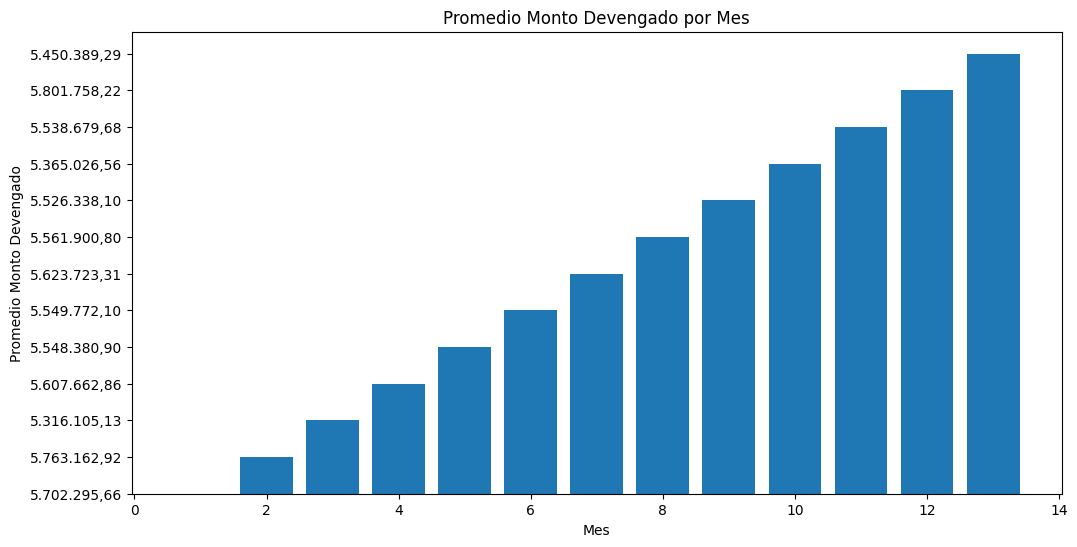

In [53]:
import matplotlib.pyplot as plt

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
plt.bar(promedio_montoDevengado_por_mes.index, promedio_montoDevengado_por_mes)
plt.xlabel('Mes')
plt.ylabel('Promedio Monto Devengado')
plt.title('Promedio Monto Devengado por Mes')
plt.show()